In [1]:
import numpy as np
import arviz as az 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import stan
from os.path import exists
import pickle
import os
import json
from multiprocessing import Pool
!pip install multiprocess
import pickle 
%matplotlib inline
import glob
import itertools
import nest_asyncio
import time
import string
nest_asyncio.apply()

from src.model import *
from src.util import *
from src.plotting import *




<h1> Setup</h1>

In [2]:
##Set names of your dependent variable, 
##Binary indicator of pre-post,
##Window on either side of the discontinuity (must be symmetric), 
## and User ID column
outcome = 'non_covid'
indicator = 'SU_banned'
window = 30

user_column = 'user_id'

#Make some output directories
make_dir = lambda fname: os.makedirs(fname) if not os.path.exists(fname) else None
make_dir('output')
make_dir('output/figures')
make_dir('output/figures/main')
make_dir('output/figures/SI')
make_dir('output/figures/evaluation')
make_dir('output/tables/')
make_dir('output/posteriors/')
make_dir('output/median_pickles/covid/')
make_dir('output/median_pickles/noncovid/')

#Load model code
with open('./src/model.stan', 'r') as file:
    model_code = file.read() 


<h1>Data Processing</h1>

In [3]:

#Load data
all_timeseries = pd.read_csv('./dat/all_reliable_amplifier_activity_counts_10_20_22.csv')
super_user_names = all_timeseries['suspended_user'].unique()


#Get a list of all the follower for a given removed user
get_users = lambda x: all_timeseries[(all_timeseries['group']==x[0]) & (all_timeseries['suspended_user']==x[1])]['user_id'].unique()

#A function to make a dataframe for for followers relevant to each condition. 
def make_condition_df(condition):
    users = get_users(condition)
    df = pd.DataFrame({'users':users})
    df['group'] = condition[0]
    df['suspended_user'] = condition[1]
    
    df1 = df.copy()
    df2 = df.copy()
    df1['outcome'] = 'non_covid_tweets'
    df2['outcome'] = 'covid_tweets'
    
    df = pd.concat([df1,df2])
    df['posterior_location'] = './output/posteriors/'+df['outcome'] + '_' + df['suspended_user'] + '_' + df['users'].astype(str) + '.json'
    df['completed'] = False
    
    return df


#Create a list of all unique conditions
all_conditions = list(itertools.product(['median','top'],super_user_names))

#Create a dataframe for each condition, use this to construct a df tracking files to process 
processing_df = pd.concat([make_condition_df(condition) for condition in all_conditions])
processing_df.to_csv('./output/processing_df.csv',index=False)


#Create a directory to store data for each follower 
make_dir('./output/split_data/')

#This function splits the data by follower and saves it to a unique csv 
split_row = lambda row: all_timeseries[(all_timeseries['group']==row['group']) & 
               (all_timeseries['suspended_user']==row['suspended_user']) & 
               (all_timeseries['user_id']==row['users'])].to_csv('./output/split_data/'+row['suspended_user']+'_'+str(row['users'])+'.csv',index=False)

#Apply splitting to the entire dataset  
processing_df.apply(split_row,axis=1)

#Add the location of the split data file to the processing df
processing_df['raw_data_file'] = './output/split_data/'+processing_df['suspended_user']+'_'+processing_df['users'].astype(str)+'.csv'



<h2>Run the model</h2>

In [4]:


import logging
logger = logging.getLogger('pystan')
logger.addHandler(logging.NullHandler())

with open('./src/model.stan', 'r') as file:
    model_code = file.read() 



#open model code
with open('./src/model.stan', 'r') as file:
    model_code = file.read() 


for row in processing_df.iterrows():
    completed = process_row(row[1], model_code,  window=30)
    if completed:
        processing_df.loc[row[0],'completed'] = True
        processing_df.to_csv('./output/processing_df.csv',index=False)
print(sum(processing_df['completed']))
print(glob.glob('./output/posteriors/*').__len__())

1200
1200


<h1>Figure 1</h1> 

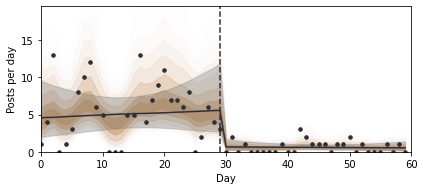

In [5]:
posteriors = glob.glob('./output/posteriors/*')
idata = az.from_json(posteriors[111])
plt.figure(figsize=(6, 11/4))

plt.scatter(np.arange(window*2), idata.observed_data.y,color=np.array([47,47,56])/255,zorder=2,s=10)


#We can extract it (it's in log scale, so we take an exp)
#It is a matrix of 4000 x window*2, containing samples from the posterior predictive distribution
exp_post = np.exp(idata.posterior_predictive.exp_hat)

    
#Our idata object has actual data, let's plot that
#Stored as seen below
plt.scatter(np.arange(window*2), idata.observed_data.y,color=np.array([47,47,56])/255,zorder=2,s=10)

#And plot various credible intervals, perhaps with shading.
for q in (1,3,6,11, 25,50,75):
    cis = np.nanpercentile(np.array(exp_post).reshape(4000,window*2), q=[0+q/2, 100-q/2],axis=0)
    plt.fill_between(np.arange(window*2), cis[0], cis[1], alpha = q/100,color= orange)

#exp_hat contains the mean function
ci = np.nanpercentile(np.exp(np.array(idata.posterior_predictive.mu_hat)).reshape(4000,window*2),
                axis=0,
                q=[5.5,50, 94.5])

#Plot the 94\% credible interval as being shaded
plt.fill_between(np.arange(window*2), ci[0], ci[2], alpha=.35, color='grey')

#Plot the median as a line
plt.plot(np.arange(window*2), ci[1], color=np.array([47,47,56])/255)

#Clean things up
plt.ylabel('Posts per day')
plt.xlabel('Day')
plt.ylim(0,np.max(idata.observed_data.y)*1.5)
plt.xlim(0,window*2)
plt.plot([window-1,window-1],
            [0, 4000],
            color=np.array([47,47,56])/255,
            ls='--')
plt.tight_layout()

plt.savefig('./output/figures/fig1.png',dpi=300)



<h1> Plotting Posteriors for all users</h1>

In [4]:
#Plot in parallel, so this doesn't take forever. 
make_dir('./output/figures/posteriors/')
import multiprocess as mp
if __name__ ==  '__main__': 
    pool = mp.Pool()
    results =  pool.map(plot_posterior_and_change, glob.glob('./output/posteriors/*'))
    pool.close()
    pool.join()


/opt/homebrew/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/homebrew/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/homebrew/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility)

KeyboardInterrupt: 

Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/lib/python3.9/site-packages/multiprocess/process.py", line 315, in _bootstrap
    self.run()
  File "/opt/homebrew/anaconda3/lib/python3.9/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/homebrew/anaconda3/lib/python3.9/site-packages/multiprocess/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/opt/homebrew/anaconda3/lib/python3.9/site-packages/multiprocess/pool.py", line 48, in mapstar
    return list(map(*args))
  File "/Users/jbb2191/Dropbox/Mac/Documents/github/TwitterSuperUserRemovals/src/plotting.py", line 77, in plot_posterior_and_change
    idata = az.from_json(posterior_location)
  File "/opt/homebrew/anaconda3/lib/python3.9/site-packages/arviz/data/io_json.py", line 29, in from_json
    idata_dict = json.load(file)


<h1>Aggregate across fits</h1>

In [10]:
#Gather median change by group, outcome, and suspended user
import multiprocess as mp
grouped =  processing_df.groupby(['group', 'outcome', 'suspended_user'])
if __name__ ==  '__main__': 
    pool = mp.Pool()
    results =  pool.map(get_median_change, grouped) 
    pool.close()
    pool.join()


In [11]:
#Gather median change by group, outcome, and suspended user
group_flattened = grouped.count().reset_index()
percentile_list = [2.5, 25, 50, 75, 97.5]
group_flattened['results'] = results

In [14]:
group = grouped.get_group(('median','non_covid_tweets'))
group

,group,outcome,suspended_user,users,posterior_location,completed,raw_data_file,results
6,median,non_covid_tweets,AlexBerenson,50,50,50,50,"[-26.870341796073582, -18.592125294554606, -38..."
7,median,non_covid_tweets,BusyDrT,50,50,50,50,"[-5.655353937764774, 30.95165880116602, -12.53..."
8,median,non_covid_tweets,IslamRizza,50,50,50,50,"[-8.402380526185647, 9.071923563326925, 0.7719..."
9,median,non_covid_tweets,RWMaloneMD,50,50,50,50,"[40.82841944001618, 57.12795226560796, 14.8353..."
10,median,non_covid_tweets,naomirwolf,50,50,50,50,"[-26.79392193815668, -22.31456651500957, -39.2..."
11,median,non_covid_tweets,pastorlocke,50,50,50,50,"[-33.32534912302155, -39.633911726053555, -32...."


<h1>Figure 2</h1>

/Users/jbb2191/Dropbox/Mac/Documents/github/TwitterSuperUserRemovals/src/plotting.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['followers'] = [np.round(follower_counts[user]/1000).astype('int') for user in group['suspended_user']]
/Users/jbb2191/Dropbox/Mac/Documents/github/TwitterSuperUserRemovals/src/plotting.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group.loc[:,str(percentile) + '%'] = group['results'].apply(lambda x: np.nanpercentile(x, percentile))
/Users/jbb2191/Dropbox/Mac/D

group                                                               top
outcome                                                non_covid_tweets
suspended_user                                                  Average
users                                                                50
posterior_location                                                   50
completed                                                            50
raw_data_file                                                        50
results               [-41.914992683650055, -57.429128972725316, -47...
followers                                                           344
3%                                                           -58.818937
11%                                                          -56.224006
25%                                                          -54.012478
50%                                                          -51.130353
75%                                                          -47

/Users/jbb2191/Dropbox/Mac/Documents/github/TwitterSuperUserRemovals/src/plotting.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group.loc[:,str(percentile) + '%'] = group['results'].apply(lambda x: np.nanpercentile(x, percentile))
/Users/jbb2191/Dropbox/Mac/Documents/github/TwitterSuperUserRemovals/src/plotting.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group.loc[:,str(percentile) + '%'] = group['results'].apply(lambda x: np.nanpercentile(x, percentile))
/Users/jbb2191/Dropbox/Mac/Documen

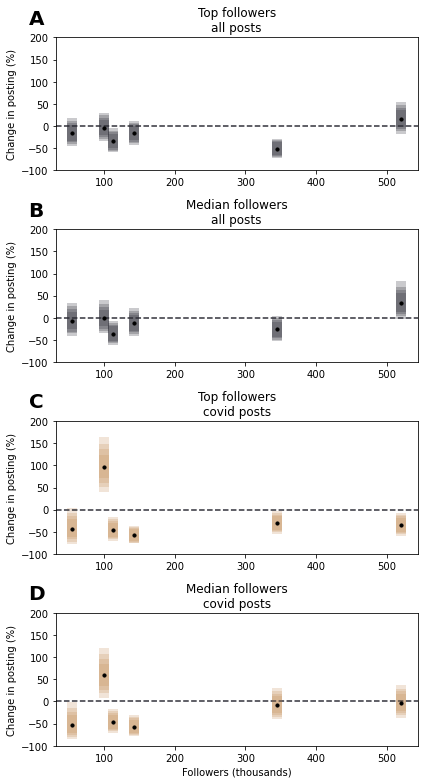

In [13]:

    
fig, axs = plt.subplots(4,1, figsize=(6,11))

grouped = group_flattened.groupby(['group','outcome'])


groups = []
plt.sca(axs[0])
group = grouped.get_group(('top','non_covid_tweets'))
plt.title('Top followers\nall posts')
groups.append(plot_change_by_group(group, ax=plt.gca(), color=grey))

plt.sca(axs[1])
plt.title('Median followers\nall posts')
group = grouped.get_group(('median','non_covid_tweets'))
groups.append(plot_change_by_group(group, ax=plt.gca(), color=grey))

plt.sca(axs[2])
plt.title('Top followers\ncovid posts')
group = grouped.get_group(('top','covid_tweets'))
groups.append(plot_change_by_group(group, ax=plt.gca(), color=orange))




plt.sca(axs[3])
plt.title('Median followers\ncovid posts')
group = grouped.get_group(('median','covid_tweets'))
groups.append(plot_change_by_group(group, ax=plt.gca(), color=orange,xlab=True))
for n, ax in enumerate(axs):
    ax.text(-0.075, 1.1, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=20, weight='bold')
plt.tight_layout()
plt.savefig('./output/figures/fig2.png',dpi=300)

<h2>Summarize chages in activity</h2>

In [15]:
changes = pd.concat(groups).drop(['users','posterior_location','completed','raw_data_file','results'],axis=1
                       ).rename({'followers':'followers (thousands)'},axis=1
                       )
changes.to_csv('./output/changes.csv',index=False)
changes = changes.groupby(['outcome','group','suspended_user']).mean()
changes.to_csv('./output/changes_grouped.csv',index=False)
changes

followers (thousands)         3%  \
outcome          group  suspended_user                                     
covid_tweets     median AlexBerenson                    344.0 -25.589447   
                        Average                         344.0 -26.035243   
                        BusyDrT                         100.0  25.332962   
                        IslamRizza                       55.0 -71.224440   
                        RWMaloneMD                      520.0 -22.870384   
                        naomirwolf                      143.0 -66.149164   
                        pastorlocke                     113.0 -57.500666   
                 top    AlexBerenson                    344.0 -41.383551   
                        Average                         344.0 -26.785740   
                        BusyDrT                         100.0  57.604444   
                        IslamRizza                       55.0 -63.615234   
                        RWMaloneMD                      520.0 -44.936968   
                        naomirwolf                      143.0 -63.857613   
                        pastorlocke                     113.0 -57.620066   
non_covid_tweets median AlexBerenson                    344.0 -39.764293   
                        Average                         344.0 -15.182319   
                        BusyDrT                         100.0 -19.859696   
                        IslamRizza                       55.0 -26.861657   
                        RWMaloneMD                      520.0  11.690287   
                        naomirwolf                      143.0 -27.606274   
                        pastorlocke                     113.0 -47.502300   
                 top    AlexBerenson                    344.0 -58.818937   
                        Average                         344.0 -23.307985   
                        BusyDrT                         100.0 -20.727845   
                        IslamRizza                       55.0 -31.197335   
                        RWMaloneMD                      520.0  -2.727119   
                        naomirwolf                      143.0 -29.380828   
                        pastorlocke                     113.0 -46.301164   

                                              11%        25%        50%  \
outcome          group  suspended_user                                    
covid_tweets     median AlexBerenson   -19.205972 -13.994570  -6.917187   
                        Average        -22.800603 -20.231640 -16.799736   
                        BusyDrT         36.450383  46.759500  59.279757   
                        IslamRizza     -65.719919 -60.062110 -52.106453   
                        RWMaloneMD     -16.331280 -10.691357  -3.004521   
                        naomirwolf     -63.113282 -60.082537 -56.542783   
                        pastorlocke    -53.928816 -50.359536 -45.764952   
                 top    AlexBerenson   -37.709571 -34.323919 -30.118686   
                        Average        -23.953295 -21.434275 -18.205512   
                        BusyDrT         70.371493  82.013106  95.947708   
                        IslamRizza     -56.798751 -50.761657 -42.691977   
                        RWMaloneMD     -41.208238 -38.005546 -33.672385   
                        naomirwolf     -61.696313 -59.598043 -56.853858   
                        pastorlocke    -53.708474 -50.036183 -45.112858   
non_covid_tweets median AlexBerenson   -35.483615 -31.374161 -26.053872   
                        Average        -12.361367  -9.925434  -7.049877   
                        BusyDrT        -13.732261  -7.724825  -0.441170   
                        IslamRizza     -20.373804 -13.987696  -6.174247   
                        RWMaloneMD      18.882996  25.105050  34.187452   
                        naomirwolf     -22.261470 -17.333569 -11.068778   
                        pastorlocke    -43.682991 -39.989306 -35.396701   
                 top    AlexBerens

<h1>Diversity Analysis</h1>

In [16]:
df_diversity = pd.read_csv('dat/all_reliable_amplifier_inequality_measurements.csv')
df_diversity.head()

,Unnamed: 0,user_id,before_suspension,after_suspension,covid_before_suspension,covid_after_suspension,non_covid_before_suspension,non_covid_after_suspension,suspended_user,measurement,group
0,0,1037541129019842560,0.677775,0.660092,0.618318,0.660960,0.655966,0.588174,AlexBerenson,gini,top
1,1,1067266550,0.705150,0.637978,0.606616,0.518125,0.688048,0.624193,AlexBerenson,gini,top
2,2,1089143694681391105,0.701304,0.666755,0.633372,0.518174,0.671774,0.653655,AlexBerenson,gini,top
3,3,1106989053054869505,0.743774,0.703384,0.663620,0.614547,0.734829,0.692828,AlexBerenson,gini,top
4,4,1110361520,0.679684,0.674712,0.597801,0.660954,0.661175,0.622337,AlexBerenson,gini,top


In [24]:
shannon = df_diversity[df_diversity['measurement']=='shannon']
gini = df_diversity[df_diversity['measurement']=='gini']


In [25]:
gini_code = '''

data {
    int<lower=0> N;
    int<lower=0> N_SU;
    vector<lower=0, upper=1>[N] y; 
    int<lower=0> superuser[N];
    int<lower=0, upper=1> after[N]; 
} 

parameters {
    real alpha;
    real<lower=0> after_sigma_group;
    real<lower=0> before_sigma_group;
    vector<lower=0>[N_SU] kappa;
    vector[N_SU] before_SU_tilde;
    vector[N_SU] after_SU_tilde;

}

transformed parameters {
    vector[N_SU] before_su = before_sigma_group * before_SU_tilde;
    vector[N_SU] after_su = after_sigma_group * after_SU_tilde;
}


model { 
    vector[N] mu;
    alpha ~ normal(logit(.57), .5); //Emprical prior for grand mean
    kappa ~ exponential(1);
    before_sigma_group ~ exponential(1);
    after_sigma_group ~ exponential(1);

    before_SU_tilde ~ std_normal(); // non-centered parameterization
    after_SU_tilde ~ std_normal(); // non-centered parameterization

    for (n in 1:N){
        mu[n] = inv_logit(alpha + (1-after[n])*before_su[superuser[n]] + after[n] * after_su[superuser[n]]);
        y[n] ~ beta_proportion(mu[n], kappa[superuser[n]]);

    }

} 

generated quantities {
    vector[N_SU] change;
    vector[N_SU] before_hat;
    vector[N_SU] after_hat;
    vector[N] y_pred;
    vector[N] mu_pred;

    for(n in 1:N) {
        mu_pred[n] = inv_logit(alpha + (1-after[n])*before_su[superuser[n]] + after[n] * after_su[superuser[n]]);
        y_pred[n] = beta_proportion_rng(mu_pred[n], kappa[superuser[n]]); 
    }


    for (s in 1:N_SU){
        before_hat[s] = inv_logit(alpha + before_su[s]);
        after_hat[s] = inv_logit(alpha + after_su[s]);
        change[s] =  after_hat[s] - before_hat[s]; 
    }

} 


'''

def melt_gini(gini):
    melted = pd.melt(gini, id_vars=['id','suspended_user'],value_vars=['before_suspension', 'after_suspension'])
    melted.head()
    melted['variable'].unique()
    melted = melted.dropna()
    melted = melted[melted['value'] > 0]
    melted['value'].max()
    
    gini_data = {'N':melted.shape[0], 
              'after':np.array(melted['variable']=='after_suspension').astype('int'),
              'y':melted['value'].values,
             'superuser':pd.Categorical(melted['suspended_user']).codes.astype('int')+1,
             'userid':pd.Categorical(melted['id']).codes.astype('int')+1,
             'F':melted['id'].unique().size,
             'N_SU':melted['suspended_user'].unique().size,

              'ga':2,
               'gb':2}
    
    return melted, gini_data

gini_top = gini[gini['group']=='top']
gini_top['id'] = np.arange(gini_top.shape[0])
gini_melted_top, gini_data_top = melt_gini(gini_top) 

gini_median = gini[gini['group']=='median']
gini_median['id'] = np.arange(gini_median.shape[0])
gini_melted_median, gini_data_median = melt_gini(gini_median) 


gini_posterior_top = stan.build(gini_code, data=gini_data_top)
gini_fit_top = gini_posterior_top.sample(num_chains=4, num_samples=3000)


gini_posterior_median = stan.build(gini_code, data=gini_data_median)
gini_fit_median = gini_posterior_median.sample(num_chains=4, num_samples=3000)




Building...


/var/folders/bj/y3syvs594cz3lmwxk8fwswzr0000gq/T/ipykernel_87623/3620853927.py:91: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gini_top['id'] = np.arange(gini_top.shape[0])
/var/folders/bj/y3syvs594cz3lmwxk8fwswzr0000gq/T/ipykernel_87623/3620853927.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gini_median['id'] = np.arange(gini_median.shape[0])

Building: found in cache, done.Messages from stanc:
Warning in '/var/folders/bj/y3syvs594cz3lmwxk8fwswzr0000gq/T/httpstan_0ksnxk47/model_hb4v6kjm.stan', li

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/var/folders/bj/y3syvs594cz3lmwxk8fwswzr0000gq/T/httpstan_0ksnxk47/model_hb4v6kjm.stan', line 7, column 4: Declaration
    of arrays by placing brackets after a variable name is deprecated and
    will be removed in Stan 2.32.0. Instead use the array keyword before the
    type. This can be changed automatically using the auto-format flag to
    stanc
Warning in '/var/folders/bj/y3syvs594cz3lmwxk8fwswzr0000gq/T/httpstan_0ksnxk47/model_hb4v6kjm.stan', line 8, column 4: Declaration
    of arrays by placing brackets after a variable name is deprecated and
    will be removed in Stan 2.32.0. Instead use the array keyword before the
    type. This can be changed automatically using the auto-format flag to
    stanc
Sampling:   0%
Sampling:   0% (1/16000)
Sampling:   0% (2/16000)
Sampling:   0% (3/16000)
Sampling:   0% (4/16000)
Sampling:   1% (103/16000)
Sampling:   1% (202/16000)
Sampling:   3% (401/16000)
Sampling:   3% (501

In [26]:
def plot_gini(melted, fit,axs):
    plt.sca(axs)
    codes = pd.Categorical(melted['suspended_user']).codes
    convert_dict = json.load(open('./dat/user_followers_count.json','rb'))
    for code in np.unique(codes):
        account = melted[codes==code].iloc[0]['suspended_user']
        xloc = convert_dict[account]/1000
        mu = np.mean(fit['change'][code])
        plt.scatter(xloc, mu,color='k')#np.array([249,214,73])/255)

        for ps in [3, 6, 11, 25,50,]:
            ci = np.nanpercentile(fit['change'][code], q=[0+ps/2, 100-ps/2])
            plt.plot([xloc, xloc], [ci[0], ci[1]],
                     solid_capstyle='projecting',
                     lw=10,alpha=ps/50*.5,color=yellow)
        plt.ylim(-1, 1)
    plt.plot([0, 600],[0,0], ls='--',color='k') 
    plt.xlim(0,550)
    plt.ylabel('Change in \nGini coefficient')
    plt.xlabel('Followers (thousands)')

In [27]:
az.summary(gini_fit_median)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.279,0.086,-0.446,-0.118,0.002,0.001,2897.0,4149.0,1.0
after_sigma_group,0.486,0.196,0.195,0.847,0.003,0.002,3119.0,5481.0,1.0
before_sigma_group,0.187,0.101,0.022,0.373,0.002,0.001,3298.0,3120.0,1.0
kappa[0],3.127,0.399,2.380,3.869,0.004,0.003,12269.0,9038.0,1.0
kappa[1],12.397,1.700,9.225,15.663,0.014,0.010,14196.0,8672.0,1.0
...,...,...,...,...,...,...,...,...,...
mu_pred[588],0.381,0.023,0.337,0.425,0.000,0.000,16210.0,9882.0,1.0
mu_pred[589],0.381,0.023,0.337,0.425,0.000,0.000,16210.0,9882.0,1.0
mu_pred[590],0.381,0.023,0.337,0.425,0.000,0.000,16210.0,9882.0,1.0
mu_pred[591],0.381,0.023,0.337,0.425,0.000,0.000,16210.0,9882.0,1.0


In [28]:
az.summary(gini_fit_top)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.327,0.068,0.195,0.452,0.001,0.001,2859.0,4161.0,1.0
after_sigma_group,0.177,0.096,0.039,0.360,0.002,0.001,2688.0,4069.0,1.0
before_sigma_group,0.283,0.120,0.108,0.495,0.002,0.002,2808.0,5373.0,1.0
kappa[0],14.233,2.006,10.540,17.985,0.017,0.012,13232.0,8206.0,1.0
kappa[1],16.925,2.368,12.421,21.207,0.020,0.014,13828.0,7881.0,1.0
...,...,...,...,...,...,...,...,...,...
mu_pred[591],0.591,0.016,0.563,0.624,0.000,0.000,13604.0,9717.0,1.0
mu_pred[592],0.591,0.016,0.563,0.624,0.000,0.000,13604.0,9717.0,1.0
mu_pred[593],0.591,0.016,0.563,0.624,0.000,0.000,13604.0,9717.0,1.0
mu_pred[594],0.591,0.016,0.563,0.624,0.000,0.000,13604.0,9717.0,1.0


<h2>Shannon Diversity</h2>

In [29]:
shannon_code = '''

data {
    int<lower=0> N;
    int<lower=0> N_SU;
    vector<lower=0>[N] y; 
    int<lower=0> superuser[N];
    int<lower=0, upper=1> after[N]; 
} 

parameters {
    real alpha;
    real<lower=0> after_sigma_group;
    real<lower=0> before_sigma_group;
    vector<lower=0>[N_SU] kappa;
    vector[N_SU] before_SU_tilde;
    vector[N_SU] after_SU_tilde;

}

transformed parameters {
    vector[N_SU] before_su = before_sigma_group * before_SU_tilde;
    vector[N_SU] after_su = after_sigma_group * after_SU_tilde;
    
}


model { 
    vector[N] mu;

    alpha ~ normal(logit(.57), .5); //Emprical prior for grand mean
    kappa ~ exponential(1);
    before_sigma_group ~ exponential(1);
    after_sigma_group ~ exponential(1);


    before_SU_tilde ~ std_normal(); // non-centered parameterization
    after_SU_tilde ~ std_normal(); // non-centered parameterization

    for (n in 1:N){
        mu[n] = exp(alpha + (1-after[n])*before_su[superuser[n]] + after[n] * after_su[superuser[n]]);
        y[n] ~ gamma(kappa[superuser[n]], mu[n]/kappa[superuser[n]]);

    }

} 


generated quantities {

    vector[N_SU] change;
    vector[N_SU] before_hat;
    vector[N_SU] after_hat;
    vector[N] y_pred;
    vector[N] mu_pred;

    for(n in 1:N) {
        mu_pred[n] = exp(alpha + (1-after[n])*before_su[superuser[n]] + after[n] * after_su[superuser[n]]);
        y_pred[n] = gamma_rng(kappa[superuser[n]], mu_pred[n]/kappa[superuser[n]]); 
    }


    for (s in 1:N_SU){
        before_hat[s] = inv_logit(alpha + before_su[s]);
        after_hat[s] = inv_logit(alpha + after_su[s]);
        change[s] =  after_hat[s] - before_hat[s]; 
    }
} 


'''


def melt_shannon(shannon):
    melted = pd.melt(shannon, id_vars=['id','suspended_user'],value_vars=['before_suspension', 'after_suspension'])
    melted.head()
    melted['variable'].unique()
    melted = melted.dropna()
    melted = melted[melted['value'] > 0]
    melted['value'].max()
    
    shannon_data = {'N':melted.shape[0], 
              'after':np.array(melted['variable']=='after_suspension').astype('int'),
              'y':melted['value'].values,
             'superuser':pd.Categorical(melted['suspended_user']).codes.astype('int')+1,
             'userid':pd.Categorical(melted['id']).codes.astype('int')+1,
             'F':melted['id'].unique().size,
             'N_SU':melted['suspended_user'].unique().size,

              'ga':2,
               'gb':2}
    
    return melted, shannon_data

shannon_top = shannon[shannon['group']=='top']
shannon_top['id'] = np.arange(shannon_top.shape[0])
shannon_melted_top, shannon_data_top = melt_shannon(shannon_top) 

shannon_median = shannon[shannon['group']=='median']
shannon_median['id'] = np.arange(shannon_median.shape[0])
shannon_melted_median, shannon_data_median = melt_shannon(shannon_median) 



shannon_posterior_median = stan.build(shannon_code, data=shannon_data_median)
shannon_fit_median = shannon_posterior_median.sample(num_chains=4, num_samples=3000)

shannon_posterior_top = stan.build(shannon_code, data=shannon_data_top)
shannon_fit_top = shannon_posterior_top.sample(num_chains=4, num_samples=3000)



Building...


/var/folders/bj/y3syvs594cz3lmwxk8fwswzr0000gq/T/ipykernel_87623/1766112243.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shannon_top['id'] = np.arange(shannon_top.shape[0])
/var/folders/bj/y3syvs594cz3lmwxk8fwswzr0000gq/T/ipykernel_87623/1766112243.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shannon_median['id'] = np.arange(shannon_median.shape[0])

Building: found in cache, done.Messages from stanc:
Warning in '/var/folders/bj/y3syvs594cz3lmwxk8fwswzr0000gq/T/httpstan_qgj4af4_/model_qqtdz

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/var/folders/bj/y3syvs594cz3lmwxk8fwswzr0000gq/T/httpstan_qgj4af4_/model_qqtdzjml.stan', line 7, column 4: Declaration
    of arrays by placing brackets after a variable name is deprecated and
    will be removed in Stan 2.32.0. Instead use the array keyword before the
    type. This can be changed automatically using the auto-format flag to
    stanc
Warning in '/var/folders/bj/y3syvs594cz3lmwxk8fwswzr0000gq/T/httpstan_qgj4af4_/model_qqtdzjml.stan', line 8, column 4: Declaration
    of arrays by placing brackets after a variable name is deprecated and
    will be removed in Stan 2.32.0. Instead use the array keyword before the
    type. This can be changed automatically using the auto-format flag to
    stanc
Sampling:   0%
Sampling:   0% (1/16000)
Sampling:   0% (2/16000)
Sampling:   0% (3/16000)
Sampling:   0% (4/16000)
Sampling:   1% (103/16000)
Sampling:   1% (202/16000)
Sampling:   2% (301/16000)
Sampling:   2% (400

In [30]:
az.summary(shannon_fit_median)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,3.083,0.118,2.857,3.298,0.002,0.002,2421.0,2242.0,1.0
after_sigma_group,0.045,0.064,0.000,0.133,0.004,0.003,899.0,276.0,1.0
before_sigma_group,0.048,0.062,0.000,0.143,0.004,0.003,893.0,289.0,1.0
kappa[0],10.360,0.674,9.065,11.564,0.019,0.014,1552.0,834.0,1.0
kappa[1],10.077,0.635,8.892,11.260,0.014,0.010,1987.0,1120.0,1.0
...,...,...,...,...,...,...,...,...,...
mu_pred[593],22.139,2.824,16.877,27.201,0.064,0.048,2385.0,1349.0,1.0
mu_pred[594],22.139,2.824,16.877,27.201,0.064,0.048,2385.0,1349.0,1.0
mu_pred[595],22.139,2.824,16.877,27.201,0.064,0.048,2385.0,1349.0,1.0
mu_pred[596],22.139,2.824,16.877,27.201,0.064,0.048,2385.0,1349.0,1.0


In [31]:
az.summary(shannon_fit_top)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.897,0.496,0.963,2.771,0.010,0.007,2256.0,4625.0,1.0
after_sigma_group,1.550,0.586,0.626,2.660,0.011,0.008,2551.0,4036.0,1.0
before_sigma_group,1.560,0.606,0.586,2.656,0.012,0.008,2523.0,4646.0,1.0
kappa[0],4.994,0.681,3.766,6.323,0.006,0.004,12086.0,7535.0,1.0
kappa[1],13.348,1.904,9.928,16.972,0.019,0.013,10441.0,8607.0,1.0
...,...,...,...,...,...,...,...,...,...
mu_pred[592],26.563,7.492,13.209,40.202,0.074,0.053,10338.0,8230.0,1.0
mu_pred[593],26.563,7.492,13.209,40.202,0.074,0.053,10338.0,8230.0,1.0
mu_pred[594],26.563,7.492,13.209,40.202,0.074,0.053,10338.0,8230.0,1.0
mu_pred[595],26.563,7.492,13.209,40.202,0.074,0.053,10338.0,8230.0,1.0


In [32]:
gini_melted_top

,id,suspended_user,variable,value
0,0,AlexBerenson,before_suspension,0.677775
1,1,AlexBerenson,before_suspension,0.705150
2,2,AlexBerenson,before_suspension,0.701304
3,3,AlexBerenson,before_suspension,0.743774
4,4,AlexBerenson,before_suspension,0.679684
...,...,...,...,...
594,294,RWMaloneMD,after_suspension,0.610152
595,295,RWMaloneMD,after_suspension,0.646763
596,296,RWMaloneMD,after_suspension,0.612568
597,297,RWMaloneMD,after_suspension,0.608040


In [33]:

def adjust(x, window=30):
    return 100*x / np.median(x[:window])

def plot_gini(melted, fit,axs, ylim=.2):
    plt.sca(axs)
    codes = pd.Categorical(melted['suspended_user']).codes
    convert_dict = json.load(open('./dat/user_followers_count.json','rb'))
    for code in np.unique(codes):
        account = melted[codes==code].iloc[0]['suspended_user']
        xloc = convert_dict[account]/1000
        mu = np.mean(fit['change'][code])
        plt.scatter(xloc, mu,color='k')#np.array([249,214,73])/255)

        for ps in [3, 6, 11, 25,50,]:
            ci = np.nanpercentile(fit['change'][code], q=[0+ps/2, 100-ps/2])
            plt.plot([xloc, xloc], [ci[0], ci[1]],
                     solid_capstyle='projecting',
                     lw=10,alpha=ps/50*.5,color=yellow)
        plt.ylim(-ylim, ylim)
    ci = np.nanpercentile(np.mean(fit['change'],axis=0), q=[3, 97])
    mu = np.nanmean(fit['change'])#, q=[3, 97])

    #plt.plot([0,600], [mu, mu], color='k')
    #plt.fill_between([0, 600], [ci[0], ci[0]], [ci[1], ci[1]], color=yellow, alpha=.25)
    plt.plot([0, 600],[0,0], ls='--',color='k') 
    plt.xlim(0,550)
    plt.ylabel('Change in \nGini coefficient')
    plt.xlabel('Followers (thousands)')

def plot_shannon(melted, fit,axs, ylim=.2):
    plt.sca(axs)
    codes = pd.Categorical(melted['suspended_user']).codes
    convert_dict = json.load(open('./dat/user_followers_count.json','rb'))
    for code in np.unique(codes):
        account = melted[codes==code].iloc[0]['suspended_user']
        xloc = convert_dict[account]/1000
        mu = np.mean(fit['change'][code])
        plt.scatter(xloc, mu,color='k',zorder=1)#np.array([249,214,73])/255)

        for ps in [3, 6, 11, 25,50,]:
            ci = np.nanpercentile(fit['change'][code], q=[0+ps/2, 100-ps/2])
            plt.plot([xloc, xloc], [ci[0], ci[1]],
                     solid_capstyle='projecting',
                     lw=10,alpha=ps/50*.5,color=red,zorder=2)
    #plt.plot([0,600], [mu, mu], color='k',zorder=3)
    #plt.fill_between([0, 600], [ci[0], ci[0]], [ci[1], ci[1]], color=red, alpha=.25,zorder=1)
    plt.ylim(-ylim, ylim)
    plt.plot([0, 600],[0,0], ls='--',color='k') 
    plt.xlim(0,550)
    plt.ylabel('Change in \nShannon Diversity (bits)')
    plt.xlabel('Followers (thousands)')

        


<h1>Figure 3</h1>

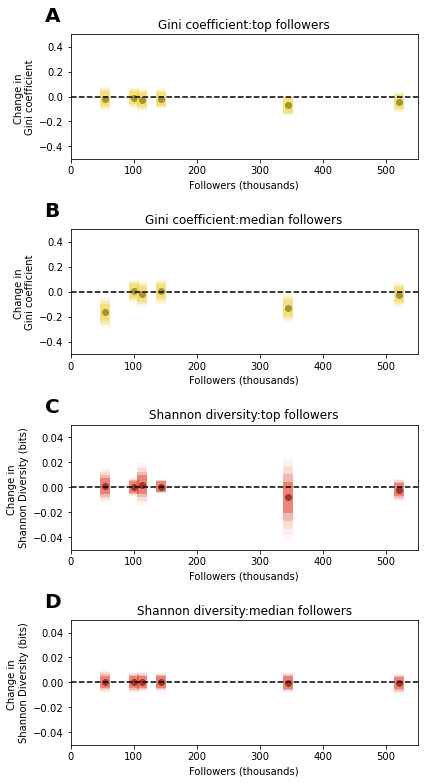

In [177]:
fig, axs = plt.subplots(4,1, figsize=(6,11))

plot_gini(gini_melted_top, gini_fit_top,axs[0],ylim=.5)
plt.title('Gini coefficient:top followers')
plot_gini(gini_melted_median, gini_fit_median,axs[1],ylim=.5)
plt.title('Gini coefficient:median followers')


plot_shannon(shannon_melted_top, shannon_fit_top,axs[2],ylim=.05)
plt.title('Shannon diversity:top followers')
plot_shannon(shannon_melted_median, shannon_fit_median,axs[3],ylim=.05)
plt.title('Shannon diversity:median followers')

plt.tight_layout()

for n, ax in enumerate(axs):
    ax.text(-0.075, 1.1, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=20, weight='bold')
plt.tight_layout()
plt.savefig('./output/figures/fig3.png',dpi=300)